Sampled values this run:
✓ ReplayCompose
  ✓ ShiftScaleRotate  →  rotate=-0.9599, scale={x=1.0000, y=1.0000}
  ✓ ElasticTransform
  · OneOf
    · GaussianBlur
    · MedianBlur
    · MotionBlur
  ✓ GaussNoise
  · ISONoise
  · ImageCompression
  ✓ RandomBrightnessContrast  →  alpha=1.0766, beta=5.0852
  · Downscale


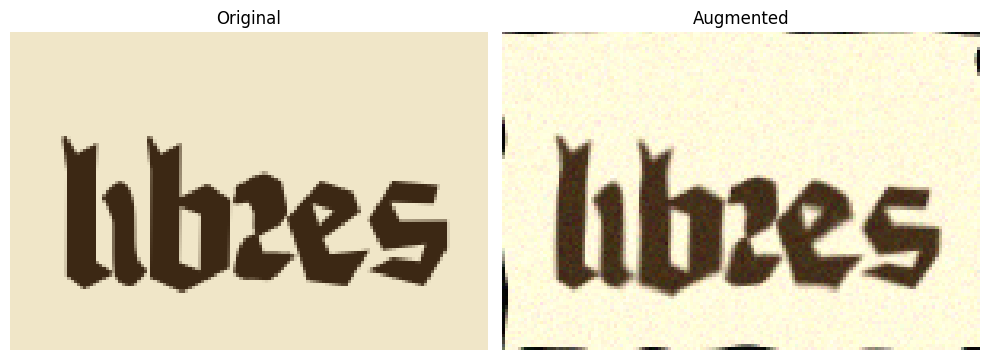

In [56]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path
from dotenv import load_dotenv
from PIL import Image, ImageDraw, ImageFont
load_dotenv()
project_root = Path(os.environ.get("PROJECT_ROOT", "."))


def describe_replay(replay, indent=0):
    """Print which transforms were applied this call and the values they sampled.

    Recurses into Compose / OneOf containers. For each leaf transform, prints
    an ✓/✗ for whether it ran this call, and the scalar parameters that were
    sampled (internal arrays like noise_map and affine matrices are skipped).
    """
    SKIP_KEYS = {
        "noise_map", "matrix", "bbox_matrix", "shape", "output_shape",
        "interpolation", "mask_interpolation", "fill", "fill_mask",
    }

    def fmt(v):
        if isinstance(v, float):
            return f"{v:.4f}"
        if isinstance(v, dict):
            return "{" + ", ".join(f"{k}={fmt(vv)}" for k, vv in v.items()) + "}"
        if isinstance(v, (list, tuple)):
            return "(" + ", ".join(fmt(x) for x in v) + ")"
        return repr(v)

    if not isinstance(replay, dict):
        return
    name = replay.get("__class_fullname__", "?").rsplit(".", 1)[-1]
    applied = replay.get("applied", False)
    mark = "✓" if applied else "·"
    prefix = "  " * indent

    if "transforms" in replay:
        print(f"{prefix}{mark} {name}")
        for t in replay["transforms"]:
            describe_replay(t, indent + 1)
        return

    params = replay.get("params") or {}
    clean = {}
    for k, v in params.items():
        if k in SKIP_KEYS:
            continue
        if hasattr(v, "shape") and getattr(v, "ndim", 0) >= 1:
            continue  # drop ndarray fields
        clean[k] = v
    param_str = ", ".join(f"{k}={fmt(v)}" for k, v in clean.items())
    suffix = f"  →  {param_str}" if param_str else ""
    print(f"{prefix}{mark} {name}{suffix}")


# Define your augmentation pipeline — ReplayCompose records every sampled value
transform = A.ReplayCompose([
    # Geometric transforms
    A.ShiftScaleRotate(
        shift_limit=0.02,      # 2% shift
        scale_limit=0,         # no scaling
        rotate_limit=4,        # ±4° rotation
        border_mode=cv2.BORDER_REPLICATE,
        p=0.8
    ),

    # Elastic distortion
    A.ElasticTransform(
        alpha=50,
        sigma=5,
        p=0.5
    ),

    # Blur variations
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 7), p=0.5),
        A.MedianBlur(blur_limit=(3, 7), p=0.5),
        A.MotionBlur(blur_limit=(3, 5), p=0.5),
    ], p=0.4),

    # Noise — std_range is in normalized [0, 1] units (≈ old var_limit (10, 50))
    A.GaussNoise(std_range=(0.012, 0.028), p=0.6),
    A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=0.3),

    # Compression artifacts
    A.ImageCompression(quality_range=(70, 90), compression_type="jpeg", p=0.4),

    # Lighting/contrast
    A.RandomBrightnessContrast(
        brightness_limit=0.1,
        contrast_limit=0.1,
        p=0.7
    ),

    # Simulate scan quality
    A.Downscale(scale_range=(0.5, 0.9), p=0.3),
])

img = cv2.imread(str(project_root / "tests/augmentation/merged_claude_cmpl_libre.png"))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

out = transform(image=img)
augmented = out["image"]

print("Sampled values this run:")
describe_replay(out["replay"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(augmented); axes[1].set_title("Augmented"); axes[1].axis("off")
plt.tight_layout()
plt.show()

Saved 66 crops to /Users/camilabermudezvalderrama/Documents/LMU-STATISTICS & DATA SCIENCE MASTER/SS2026/Thesis/OCC_HTR/tests/augmentation/parchment_crops
Mean edge score across kept crops: 1.50


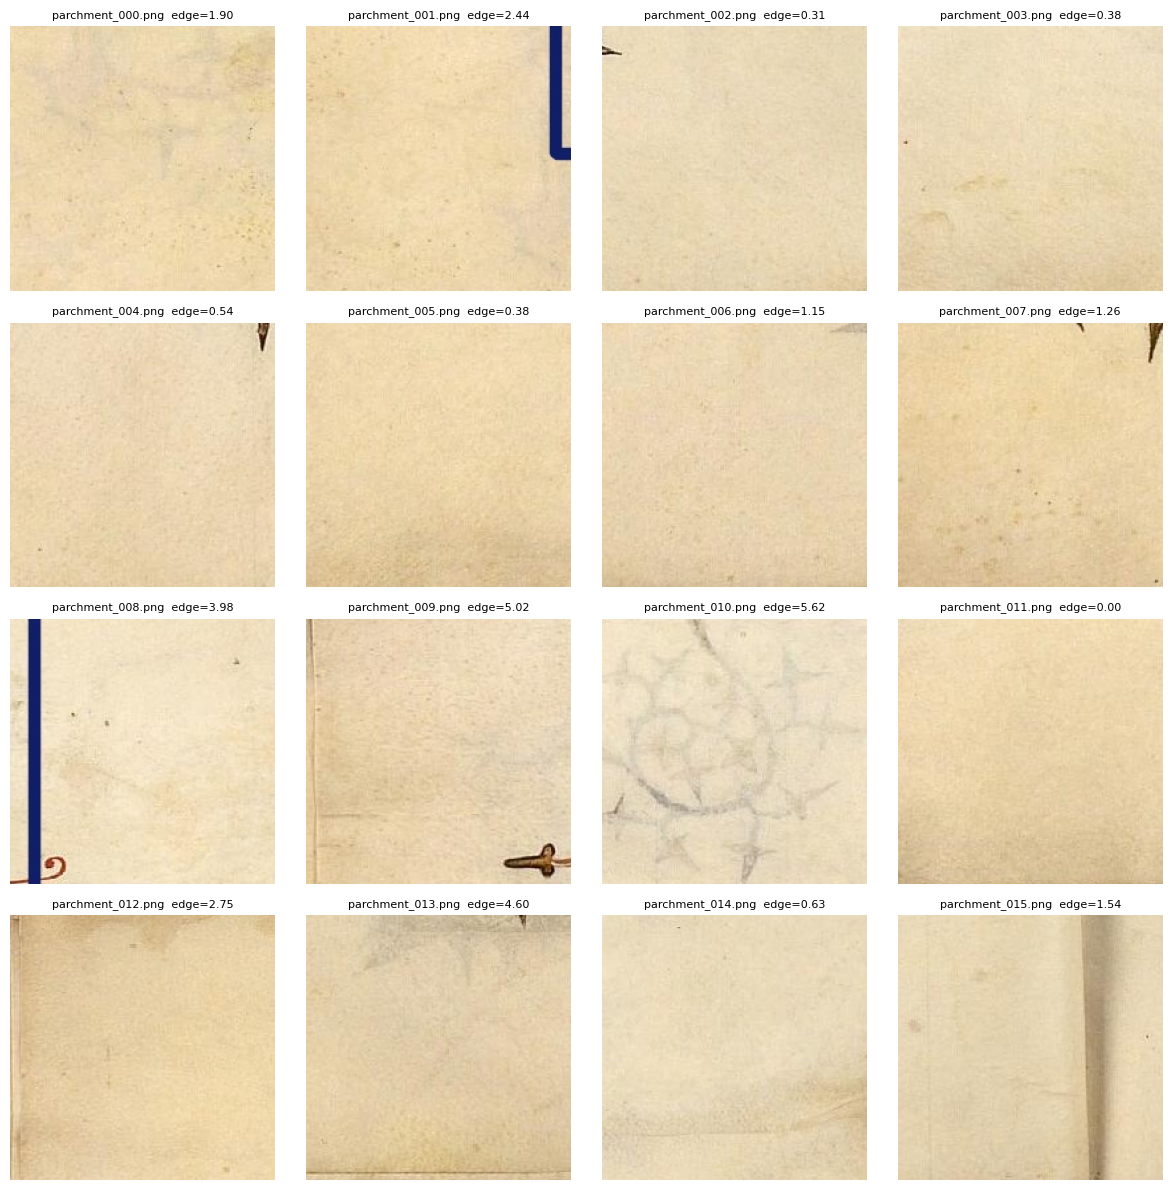

In [57]:
# Auto-extract empty parchment crops from manuscript pages.
# Run this ONCE before Option A.
#
# Strategy: for each page, sample random fixed-size windows, score each by
# edge density (Canny). Empty parchment scores near zero; text-heavy regions
# score high. Keep the lowest-scoring windows per page.
#
# This is heuristic — after it runs, OPEN the output directory and DELETE
# any crops that snuck in text fragments or illuminated initials. Aim to
# keep 15–30 clean crops.

import random
import numpy as np

PAGES_DIR = project_root / "runs/detect/predict-8"
OUTPUT_DIR = project_root / "tests/augmentation/parchment_crops"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CROP_SIZE = 200             # square crop in pixels
CANDIDATES_PER_PAGE = 40    # random windows considered per page
KEEP_PER_PAGE = 3           # lowest-edge crops actually kept per page
EDGE_THRESHOLD = 6.0        # reject crops with Canny mean above this (lower = stricter)

random.seed(0)
np.random.seed(0)

page_files = sorted(PAGES_DIR.glob("*.jpg")) + sorted(PAGES_DIR.glob("*.png"))
assert page_files, f"No pages found in {PAGES_DIR}"

# Clear any previous run so reruns don't accumulate stale crops.
for old in OUTPUT_DIR.glob("parchment_*.png"):
    old.unlink()

saved = []
for page_path in page_files:
    page = cv2.imread(str(page_path))
    if page is None:
        continue
    page = cv2.cvtColor(page, cv2.COLOR_BGR2RGB)
    h, w = page.shape[:2]
    if h < CROP_SIZE or w < CROP_SIZE:
        continue

    candidates = []
    for _ in range(CANDIDATES_PER_PAGE):
        y = random.randint(0, h - CROP_SIZE)
        x = random.randint(0, w - CROP_SIZE)
        crop = page[y:y + CROP_SIZE, x:x + CROP_SIZE]
        gray = cv2.cvtColor(crop, cv2.COLOR_RGB2GRAY)
        edges = cv2.Canny(gray, 50, 150)
        score = float(edges.mean())
        candidates.append((score, crop))

    candidates.sort(key=lambda c: c[0])
    for score, crop in candidates[:KEEP_PER_PAGE]:
        if score > EDGE_THRESHOLD:
            continue
        idx = len(saved)
        out_path = OUTPUT_DIR / f"parchment_{idx:03d}.png"
        cv2.imwrite(str(out_path), cv2.cvtColor(crop, cv2.COLOR_RGB2BGR))
        saved.append((out_path, score, crop))

print(f"Saved {len(saved)} crops to {OUTPUT_DIR}")
print(f"Mean edge score across kept crops: {np.mean([s for _, s, _ in saved]):.2f}" if saved else "")

# Preview grid so you can visually screen for crops that should be deleted.
n = min(len(saved), 16)
if n:
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
    axes = np.array(axes).reshape(rows, cols)
    for i in range(rows * cols):
        ax = axes[i // cols, i % cols]
        if i < n:
            path, score, crop = saved[i]
            ax.imshow(crop)
            ax.set_title(f"{path.name}  edge={score:.2f}", fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


Sample 1 sampled values:
✓ ReplayCompose
  · Morphological
  ✓ Morphological
  · PixelDropout
  ✓ Lambda
  · HueSaturationValue
  ✓ OneOf
    · ElasticTransform
    ✓ ElasticTransform
  · ShiftScaleRotate
  ✓ GaussianBlur
  ✓ GaussNoise
  ✓ PlasmaBrightnessContrast  →  brightness_factor=-0.1238, contrast_factor=-0.0002

Sample 2 sampled values:
✓ ReplayCompose
  · Morphological
  ✓ Morphological
  · PixelDropout
  ✓ Lambda
  · HueSaturationValue
  · OneOf
    · ElasticTransform
    · ElasticTransform
  ✓ ShiftScaleRotate  →  rotate=-2.1028, scale={x=1.0000, y=1.0000}
  ✓ GaussianBlur
  · GaussNoise
  · PlasmaBrightnessContrast

Sample 3 sampled values:
✓ ReplayCompose
  · Morphological
  · Morphological
  · PixelDropout
  ✓ Lambda
  · HueSaturationValue
  ✓ OneOf
    ✓ ElasticTransform
    · ElasticTransform
  ✓ ShiftScaleRotate  →  rotate=3.9251, scale={x=1.0000, y=1.0000}
  ✓ GaussianBlur
  ✓ GaussNoise
  ✓ PlasmaBrightnessContrast  →  brightness_factor=-0.0488, contrast_factor=0.05

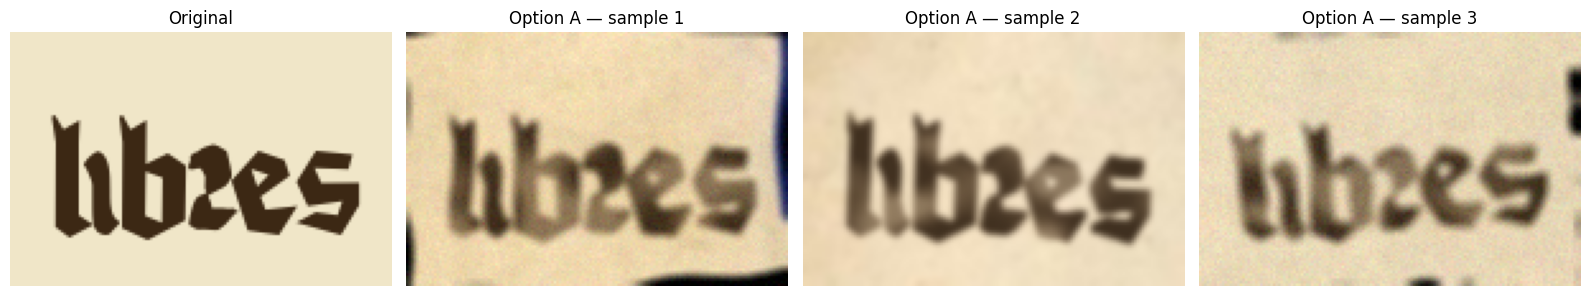

In [58]:
# OPTION A — Composite onto REAL parchment crops (translucent ink model)
# Most faithful to the true distribution. Requires real empty-region crops
# under tests/augmentation/parchment_crops/.
#
# Ink model: instead of REPLACING the parchment with a solid ink color, the
# rendered glyph is used as a per-pixel "ink density" mask that:
#   - multiplicatively DARKENS the parchment (so texture shows through), and
#   - adds a warm-brown tint where ink is dense.
# Density is modulated by a low-frequency noise field (dry-quill gaps), and
# an optional horizontally-flipped, blurred ghost simulates verso bleed-through.

import random
import numpy as np

PARCHMENT_DIR = project_root / "tests/augmentation/parchment_crops"
parchment_files = sorted(PARCHMENT_DIR.glob("*.png")) + sorted(PARCHMENT_DIR.glob("*.jpg"))
assert parchment_files, (
    f"No parchment crops found in {PARCHMENT_DIR}. "
    "Run the auto-extract cell above first, or use Option B."
)


def composite_on_parchment(image, **kwargs):
    """Composite the rendered glyph onto a real parchment crop with translucent
    iron-gall-ink behaviour: multiplicative darkening + warm tint + within-stroke
    density variation + optional verso bleed-through."""

    bg = cv2.imread(str(random.choice(parchment_files)))
    bg = cv2.cvtColor(bg, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]
    bh, bw = bg.shape[:2]
    if bh < h or bw < w:
        bg = cv2.resize(bg, (max(w, bw), max(h, bh)))
        bh, bw = bg.shape[:2]
    y0 = random.randint(0, bh - h)
    x0 = random.randint(0, bw - w)
    bg_crop = bg[y0:y0 + h, x0:x0 + w].astype(np.float32)

    # Ink density: 1 where the glyph is darkest, 0 where it's clean background.
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
    ink = np.clip((0.55 - gray) / 0.35, 0.0, 1.0)

    # Stroke noise: low-frequency random field gates ink density. Creates
    # dry-quill gaps and within-stroke variation instead of uniform thickness.
    nh, nw = max(8, h // 15), max(8, w // 15)
    coarse = np.random.rand(nh, nw).astype(np.float32)
    noise = cv2.resize(coarse, (w, h), interpolation=cv2.INTER_CUBIC)
    noise = np.clip(noise * 1.3 + 0.1, 0.4, 1.0)
    ink = ink * noise

    # Bleed-through: horizontally-flipped, heavily-blurred faint ghost of the
    # same glyph stands in for text on the back of the folio.
    bleed = np.zeros_like(ink)
    if random.random() < 0.6:
        ghost = cv2.flip(ink, 1)
        ghost = cv2.GaussianBlur(ghost, (0, 0), sigmaX=4.0)
        bleed = ghost * 0.22

    ink = ink[..., None]
    bleed = bleed[..., None]

    # Multiplicative ink model: out = bg * (mult ** density).
    # density=0 → factor 1.0 (bg unchanged). density=1 → factor `mult` per channel.
    # Asymmetric per-channel mult gives the warm sepia bias of iron-gall ink.
    ink_mult = np.array([0.27, 0.22, 0.17], dtype=np.float32)
    bleed_mult = np.array([0.88, 0.83, 0.72], dtype=np.float32)
    out = bg_crop * (bleed_mult ** bleed) * (ink_mult ** ink)
    return out.clip(0, 255).astype(np.uint8)


transform_real_bg = A.ReplayCompose([
    # 1. Ink degradation BEFORE composite. Bias toward erosion — real quill
    #    strokes have hairline thins that the rendered font lacks.
    A.Morphological(scale=(1, 2), operation="dilation", p=0.2),
    A.Morphological(scale=(1, 3), operation="erosion",  p=0.5),
    A.PixelDropout(dropout_prob=0.02, drop_value=255, p=0.3),

    # 2. Substrate swap with translucent ink + bleed-through (custom).
    A.Lambda(image=composite_on_parchment, name="composite_on_parchment", p=1.0),

    # 3. Tonal jitter — constrained to warm direction only (no pink/magenta).
    A.HueSaturationValue(
        hue_shift_limit=(0, 8),       # warm only
        sat_shift_limit=(-15, 5),     # never push saturation up
        val_shift_limit=(-15, 0),
        p=0.5,
    ),

    # 4. Page warp
    A.OneOf([
        A.ElasticTransform(alpha=50,  sigma=5,  p=1.0),
        A.ElasticTransform(alpha=120, sigma=12, p=1.0),
    ], p=0.6),
    A.ShiftScaleRotate(
        shift_limit=0.02, scale_limit=0, rotate_limit=4,
        border_mode=cv2.BORDER_REPLICATE, p=0.6,
    ),

    # 5. Scan capture
    A.GaussianBlur(blur_limit=(3, 7), p=0.4),
    A.GaussNoise(std_range=(0.012, 0.028), p=0.5),
    A.PlasmaBrightnessContrast(
        brightness_range=(-0.15, 0.05),
        contrast_range=(-0.1, 0.1),
        p=0.5,
    ),
])

img = cv2.imread(str(project_root / "tests/augmentation/merged_claude_cmpl_libre.png"))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img); axes[0].set_title("Original"); axes[0].axis("off")
for i in range(3):
    out = transform_real_bg(image=img)
    axes[i + 1].imshow(out["image"]); axes[i + 1].set_title(f"Option A — sample {i + 1}"); axes[i + 1].axis("off")
    print(f"\nSample {i + 1} sampled values:")
    describe_replay(out["replay"])
plt.tight_layout()
plt.show()


Sample 1 sampled values:
✓ ReplayCompose
  · Morphological
  · Morphological
  · PixelDropout
  ✓ ToSepia
  ✓ HueSaturationValue  →  hue_shift=-6.7835, sat_shift=-10.6880, val_shift=-25.2181
  ✓ PlasmaBrightnessContrast  →  brightness_factor=0.0554, contrast_factor=-0.0770
  ✓ PlasmaShadow  →  intensity=0.4951
  · OneOf
    · ElasticTransform
    · ElasticTransform
  ✓ ShiftScaleRotate  →  rotate=3.2887, scale={x=1.0000, y=1.0000}
  ✓ GaussianBlur
  ✓ GaussNoise
  ✓ RandomBrightnessContrast  →  alpha=0.8511, beta=-1.5107

Sample 2 sampled values:
✓ ReplayCompose
  ✓ Morphological
  · Morphological
  · PixelDropout
  ✓ ToSepia
  ✓ HueSaturationValue  →  hue_shift=-9.3372, sat_shift=-4.3641, val_shift=-6.1839
  ✓ PlasmaBrightnessContrast  →  brightness_factor=-0.1964, contrast_factor=-0.1154
  · PlasmaShadow
  · OneOf
    · ElasticTransform
    · ElasticTransform
  · ShiftScaleRotate
  ✓ GaussianBlur
  ✓ GaussNoise
  ✓ RandomBrightnessContrast  →  alpha=0.8230, beta=4.1929

Sample 3 sam

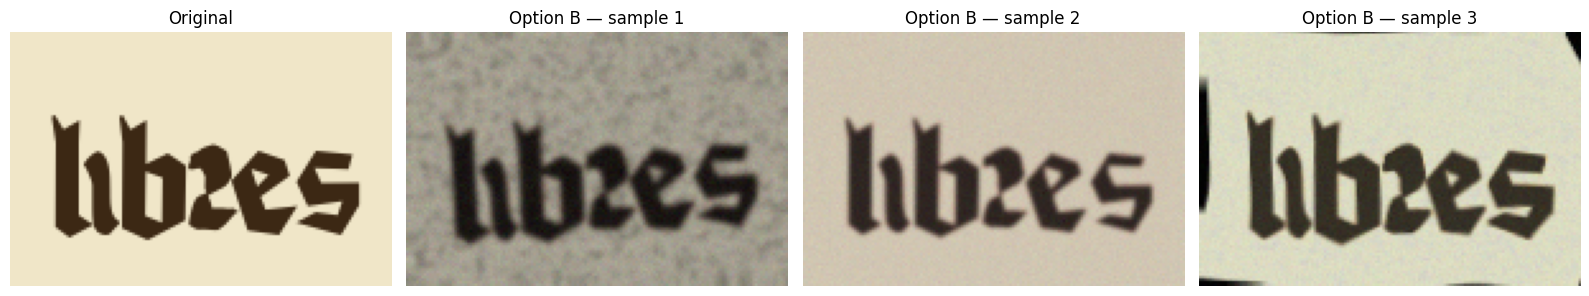

In [59]:
# OPTION B — Synthetic plasma texture (no real parchment crops needed)
# Drop-in option if you don't yet have real empty-region crops from your
# manuscript pages. Uses ToSepia + Plasma transforms to fake the parchment
# surface. Less faithful to the true distribution than Option A, but zero
# extra data required.

import numpy as np

transform_synthetic_bg = A.ReplayCompose([
    # 1. Ink degradation — applied early while strokes are still clean black
    #    (dropout to white = stroke flaking; morphological = ink pooling/fading)
    A.Morphological(scale=(1, 3), operation="dilation", p=0.3),
    A.Morphological(scale=(1, 2), operation="erosion",  p=0.3),
    A.PixelDropout(dropout_prob=0.02, drop_value=255, p=0.3),

    # 2. Push palette toward parchment/sepia BEFORE any plasma effects so the
    #    plasma modulates the already-sepia image (organic, not gray).
    A.ToSepia(p=0.8),
    A.HueSaturationValue(
        hue_shift_limit=10,
        sat_shift_limit=(-15, 15),
        val_shift_limit=(-30, 0),
        p=0.8,
    ),

    # 3. Organic low-frequency surface variation — this is what stands in
    #    for parchment texture / aging / uneven lighting.
    A.PlasmaBrightnessContrast(
        brightness_range=(-0.25, 0.1),
        contrast_range=(-0.15, 0.1),
        p=0.8,
    ),
    A.PlasmaShadow(shadow_intensity_range=(0.2, 0.5), p=0.5),

    # 4. Page warp — keep both wavelengths via OneOf
    A.OneOf([
        A.ElasticTransform(alpha=50,  sigma=5,  p=1.0),
        A.ElasticTransform(alpha=120, sigma=12, p=1.0),
    ], p=0.6),
    A.ShiftScaleRotate(
        shift_limit=0.02, scale_limit=0, rotate_limit=4,
        border_mode=cv2.BORDER_REPLICATE, p=0.6,
    ),

    # 5. Scan capture
    A.GaussianBlur(blur_limit=(3, 7), p=0.4),
    A.GaussNoise(std_range=(0.012, 0.028), p=0.6),
    A.RandomBrightnessContrast(
        brightness_limit=0.1, contrast_limit=(-0.2, 0.0), p=0.6,
    ),
])

img = cv2.imread(str(project_root / "tests/augmentation/merged_claude_cmpl_libre.png"))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img); axes[0].set_title("Original"); axes[0].axis("off")
for i in range(3):
    out = transform_synthetic_bg(image=img)
    axes[i + 1].imshow(out["image"]); axes[i + 1].set_title(f"Option B — sample {i + 1}"); axes[i + 1].axis("off")
    print(f"\nSample {i + 1} sampled values:")
    describe_replay(out["replay"])
plt.tight_layout()
plt.show()